In [1]:

import numpy as np

import matplotlib.pyplot as plt

import src_prognostics as src

%matplotlib inline

In [28]:
df = src.load_data()

In [29]:
# Get data in the HIMAP format
# df = df[df.load == 0]
data, max_len = src.format_data(df)
max_len

204

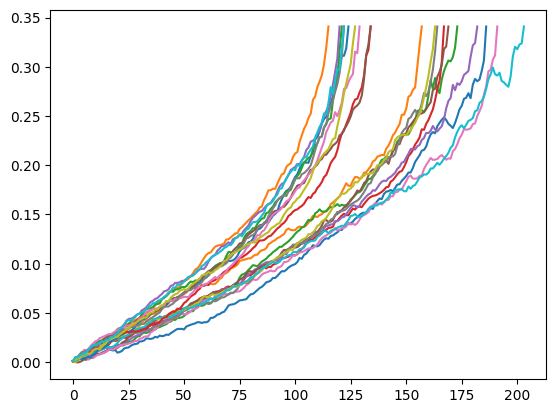

In [30]:
for traj in data.values():
    plt.plot(traj)
plt.show()

In [31]:
n_states = 4

model = src.CustomHSMM(n_states=n_states,n_durations = (max_len//n_states)*2, f_value=-0.34, obs_state_len=len(data.keys()), n_iter=3, name = 'test')


Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\dictionaries
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\figures
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models


In [32]:
model.fit(data)

Iters 1/3: 100%|██████████| 20/20 [00:07<00:00,  2.76it/s]



FIT test: re-estimation complete for loop 1 with score: -2871.514264571337.


Iters 2/3: 100%|██████████| 20/20 [00:07<00:00,  2.68it/s]



FIT test: re-estimation complete for loop 2 with score: -118.78059879975862.


Iters 3/3: 100%|██████████| 20/20 [00:05<00:00,  3.65it/s]


FIT test: re-estimation complete for loop 3 with score: -93.90591065648691.
[0, 1, 2, 3]


In [35]:
model.save_model()

Model saved to c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models\test.pkl.


In [36]:
model = src.CustomHSMM(name = 'test')
model.load_model('test')

Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\dictionaries
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\figures
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models


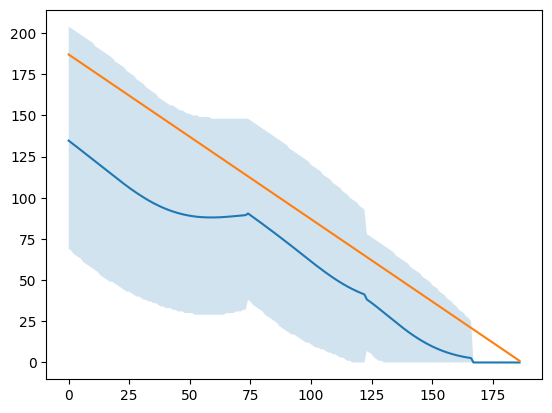

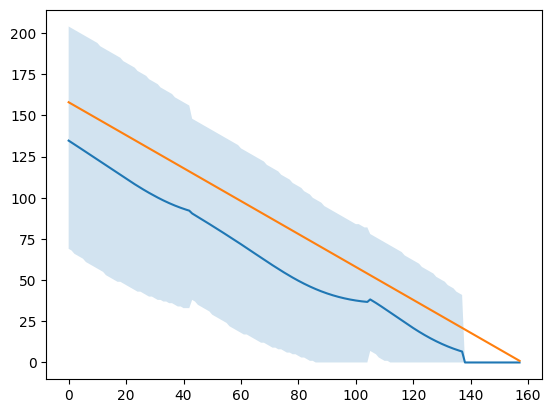

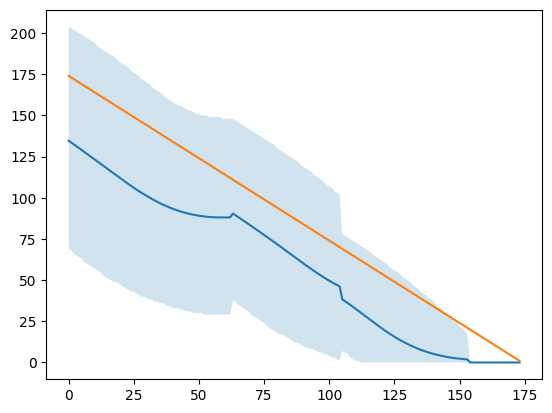

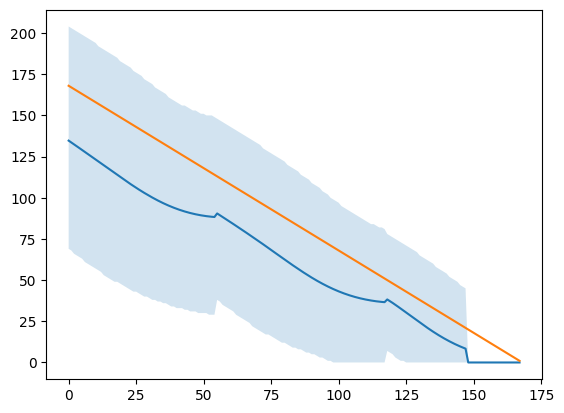

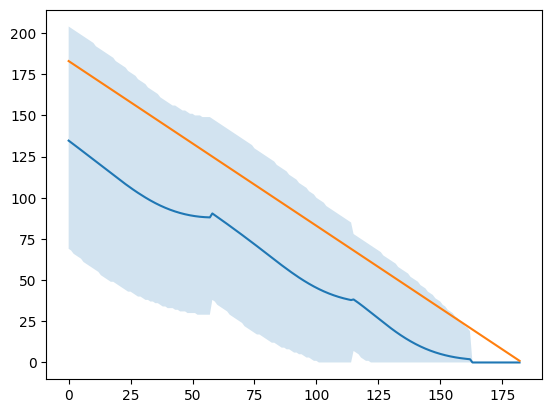

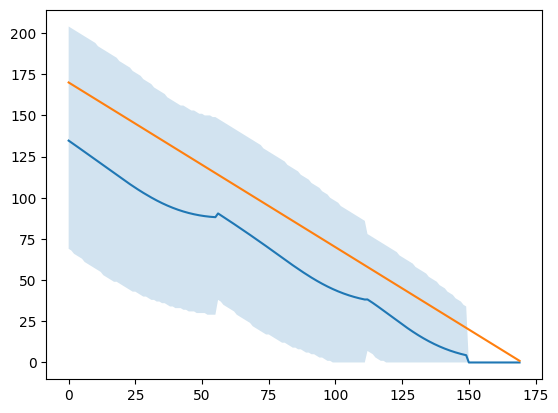

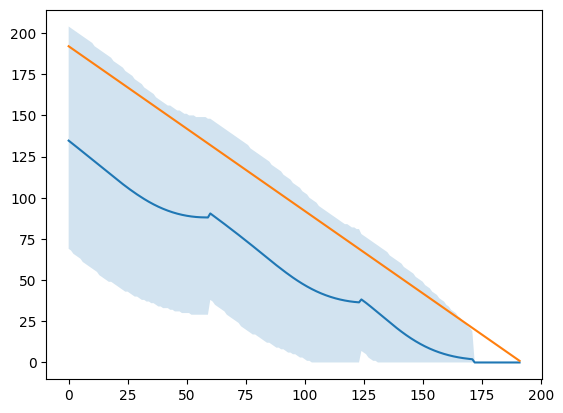

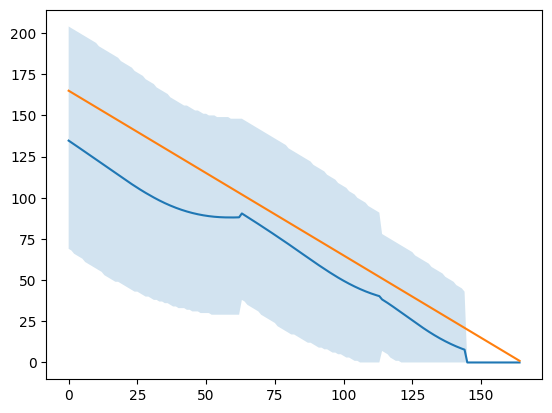

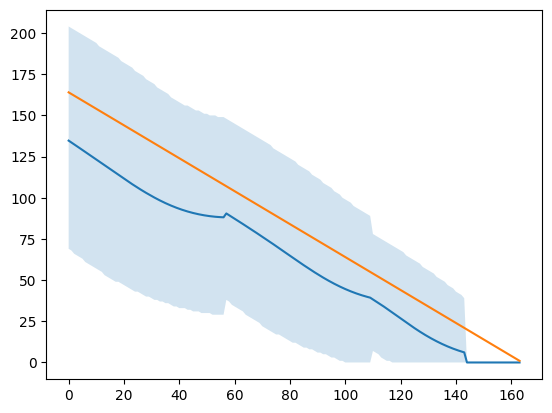

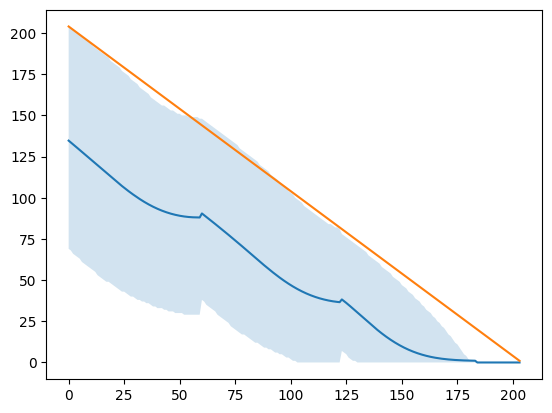

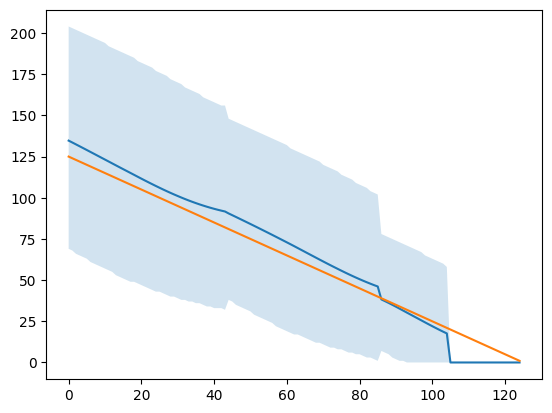

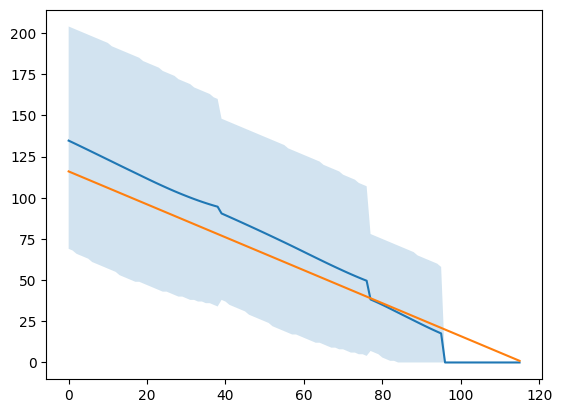

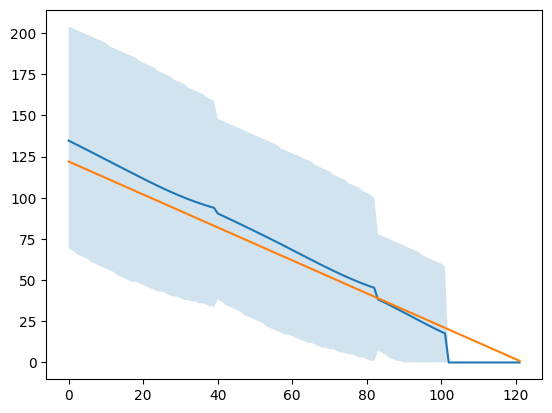

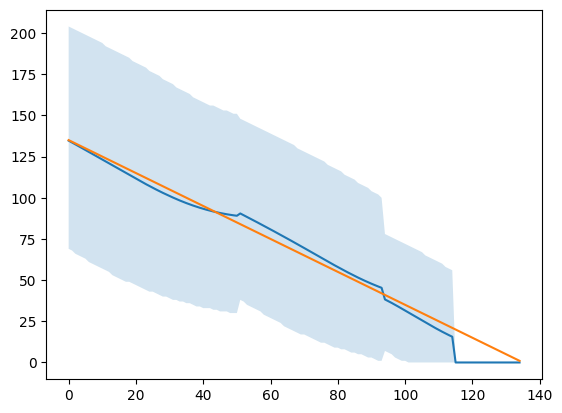

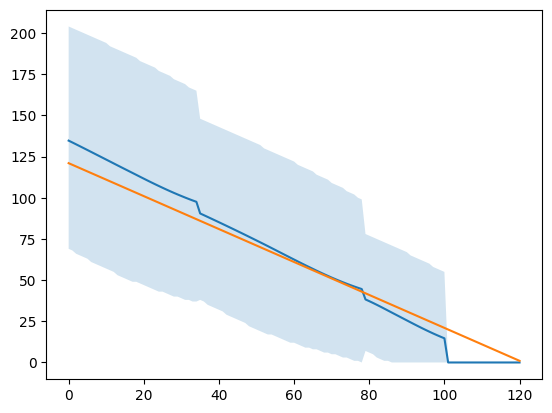

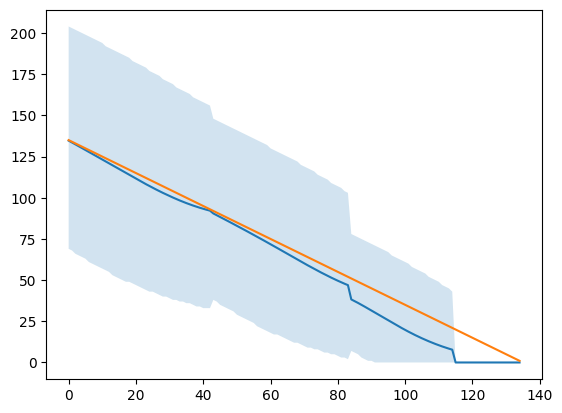

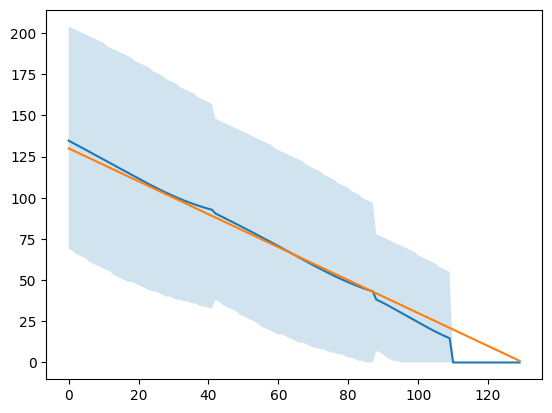

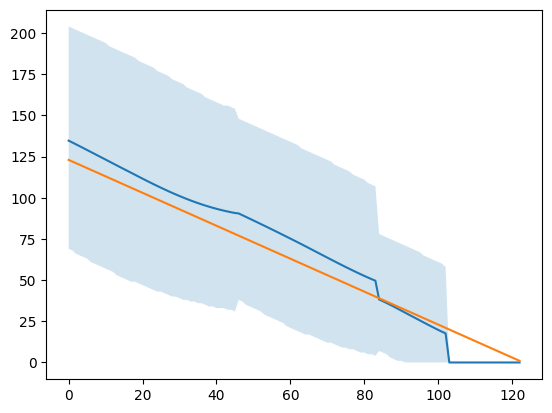

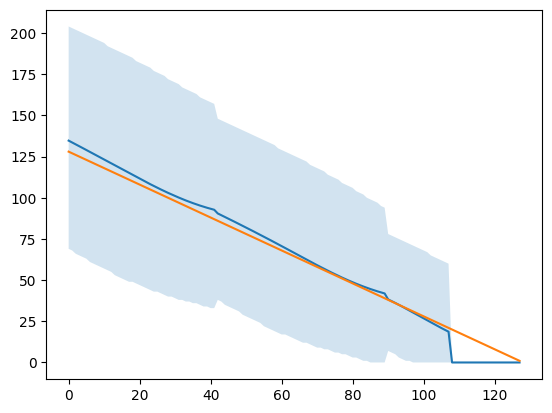

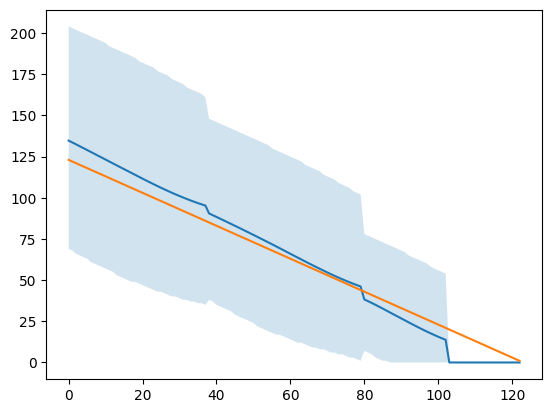

In [38]:
for X in data.values():

    expected, lb, ub = model.prognostic_bounds(X, model.max_len*3)
    
    x = np.arange(len(X))
    plt.figure()
    plt.plot(expected)
    plt.fill_between(x, lb, ub, alpha = 0.2)
    plt.plot(len(X)-x)
    plt.show()